In [ ]:
# %% 1: Environment & Dependency Imports
import os
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import keras
from keras.models import Sequential
from keras import layers
# Custom imports for evaluation and confusion matrices
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns 

In [15]:
print("TensorFlow Version:", tf.__version__)
print("Keras Version:", keras.__version__)

TensorFlow Version: 2.21.0
Keras Version: 3.15.1


In [16]:
# %% 2: Data Cleaning (Removing Corrupt Images)
DATASET_PATH = r"D:\ml\image classification"
def remove_corrupt_images(directory):
    print("Scanning for corrupted images... This might take a minute.")
    corrupt_count = 0
    processed_count = 0
    for root, _, files in os.walk(directory):
        for file in files:
            if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                file_path = os.path.join(root, file)
                processed_count += 1
                try:
                    img_bytes = tf.io.read_file(file_path)
                    tf.image.decode_image(img_bytes, channels=3, expand_animations=False)
                except Exception:
                    print(f"Corrupt file isolated and removed: {file_path}")
                    try:
                        os.remove(file_path)
                        corrupt_count += 1
                    except Exception as e:
                        print(f"Failed to delete {file_path}: {e}")
    print(f"Scan complete. Inspected {processed_count} files. Successfully removed {corrupt_count} corrupt images.")

remove_corrupt_images(DATASET_PATH)

Scanning for corrupted images... This might take a minute.
Scan complete. Inspected 24992 files. Successfully removed 0 corrupt images.


In [17]:
# %% 3: Dataset Loading (Automatic 80/20 Split)
IMAGE_SIZE = (150, 150)
BATCH_SIZE = 32
SEED = 123

In [18]:
# loading training subset
print("Loading training subset...")
train_ds = keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

Loading training subset...
Found 24991 files belonging to 2 classes.
Using 19993 files for training.


In [19]:
# loading validation subset
print("Loading validation subset...")
validation_ds = keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

Loading validation subset...
Found 24991 files belonging to 2 classes.
Using 4998 files for validation.


In [20]:
# Extract and print class identities mapped by directory scanner
class_names = train_ds.class_names
print("Detected Class Labels:", class_names)

Detected Class Labels: ['Cat', 'Dog']


In [21]:
# %% 4: Memory Optimization Pipeline
AUTOTUNE = tf.data.AUTOTUNE
# Note: We do NOT shuffle validation_ds here so that its predictions sync perfectly with its true labels
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
validation_ds_optimized = validation_ds.cache().prefetch(buffer_size=AUTOTUNE)
print("Dataset optimization layers applied successfully.")

Dataset optimization layers applied successfully.


In [23]:
# %% 5: Model Definition, Loading Logic, & Smart Conditional Training Loop
MODEL_FILE_PATH = 'cat_dog_classifier.keras'

if os.path.exists(MODEL_FILE_PATH):
    print(f"\n[INFO] Found saved model weights at '{MODEL_FILE_PATH}'!")
    print("Loading pre-trained model structure directly... This takes less than a second.")
    model = keras.models.load_model(MODEL_FILE_PATH)
    model.summary()
    
else:
    print(f"\n[INFO] No saved model found at '{MODEL_FILE_PATH}'. Initializing model architecture and training sequence...")
    
    model = Sequential([
        layers.Input(shape=(150, 150, 3)),
        layers.Rescaling(1.0/255.0),
        
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.15),
        layers.RandomZoom(0.15),
        
        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.MaxPooling2D(2, 2),
        
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D(2, 2),
        
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D(2, 2),
        
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D(2, 2),
        
        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ])


[INFO] No saved model found at 'cat_dog_classifier.keras'. Initializing model architecture and training sequence...


In [25]:
# Compile model configurations
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_1 (RandomFlip)      │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_1               │ (None, 150, 150, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_1 (RandomZoom)      │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,453,121 (13.17 MB)

 Trainable params: 3,453,121 (13.17 MB)

 Non-trainable params: 0 (0.00 B)

In [26]:
# %% 6: Model Optimization Training Loop
# Adjust EPOCHS down if testing configurations quickly
EPOCHS = 20

print("Initiating training sequence...")
history = model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=EPOCHS,
    verbose=1
)
print("Training execution routine finalized.")

Initiating training sequence...
Epoch 1/20


c:\anaconda\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


625/625 ━━━━━━━━━━━━━━━━━━━━ 179s 269ms/step - accuracy: 0.6209 - loss: 0.6409 - val_accuracy: 0.7149 - val_loss: 0.5628
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 163s 262ms/step - accuracy: 0.7086 - loss: 0.5640 - val_accuracy: 0.7503 - val_loss: 0.5146
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 162s 259ms/step - accuracy: 0.7381 - loss: 0.5227 - val_accuracy: 0.7771 - val_loss: 0.4745
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 1888s 3s/step - accuracy: 0.7633 - loss: 0.4905 - val_accuracy: 0.7865 - val_loss: 0.4498
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 151s 242ms/step - accuracy: 0.7812 - loss: 0.4655 - val_accuracy: 0.8161 - val_loss: 0.4148
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 512s 820ms/step - accuracy: 0.7889 - loss: 0.4493 - val_accuracy: 0.8195 - val_loss: 0.3967
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 150s 241ms/step - accuracy: 0.8005 - loss: 0.4323 - val_accuracy: 0.8245 - val_loss: 0.3859
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 154s 246ms/step - accuracy: 0.8118 - loss: 0.4117

In [38]:
print(f"Saving trained model to file storage at: '{MODEL_FILE_PATH}'...")

model.save(MODEL_FILE_PATH)
print("Model saved successfully! Future execution runs will bypass training.")

Saving trained model to file storage at: 'cat_dog_classifier.keras'...
Model saved successfully! Future execution runs will bypass training.


In [57]:
# 7: Display Final Evaluation (Loss & Accuracy)
print("\n--- Evaluating Model Performance on Validation Dataset ---")
eval_results = model.evaluate(validation_ds_optimized, verbose=1)
val_loss_score = eval_results[0]
val_accuracy_score = eval_results[1]

print(f"\nFinal Validation Loss: {val_loss_score:.4f}")
print(f"Final Validation Accuracy: {val_accuracy_score * 100:.2f}%")


--- Evaluating Model Performance on Validation Dataset ---
157/157 ━━━━━━━━━━━━━━━━━━━━ 11s 69ms/step - accuracy: 0.7029 - loss: 0.5655

Final Validation Loss: 0.5655
Final Validation Accuracy: 70.29%


In [58]:
# Plotting Metric Performance Charts
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

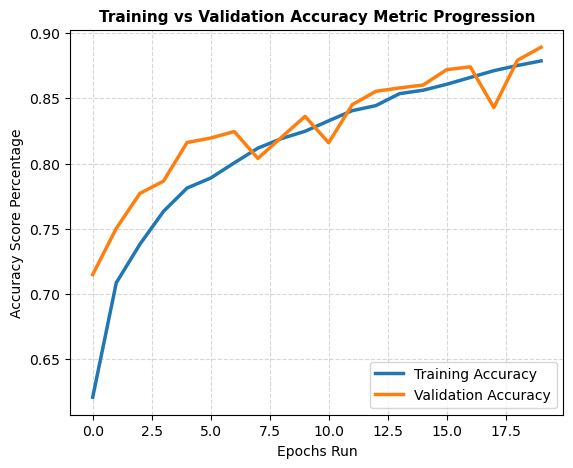

In [59]:
plt.figure(figsize=(14, 5))

# Accuracy curves subplot panel
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', color='#1f77b4', linewidth=2.5)
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='#ff7f0e', linewidth=2.5)
plt.legend(loc='lower right', fontsize=10)
plt.title('Training vs Validation Accuracy Metric Progression', fontsize=11, fontweight='bold')
plt.xlabel('Epochs Run')
plt.ylabel('Accuracy Score Percentage')
plt.grid(True, linestyle='--', alpha=0.5)

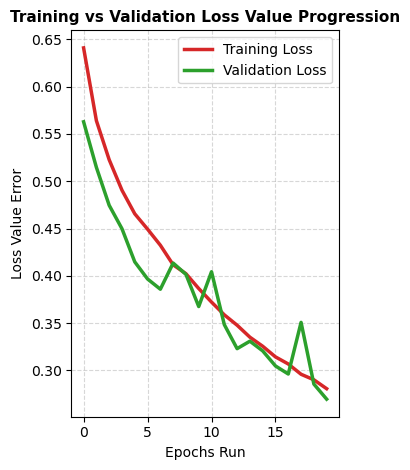

In [60]:
# Loss curves subplot panel
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', color='#d62728', linewidth=2.5)
plt.plot(epochs_range, val_loss, label='Validation Loss', color='#2ca02c', linewidth=2.5)
plt.legend(loc='upper right', fontsize=10)
plt.title('Training vs Validation Loss Value Progression', fontsize=11, fontweight='bold')
plt.xlabel('Epochs Run')
plt.ylabel('Loss Value Error')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [61]:
# 8: Collect Predictions & True Labels for Confusion Matrix
print("\nCollecting predictions from the validation set...")
true_labels = []
predicted_labels = []

# Loop through the un-shuffled validation dataset to extract real vs predicted classes
for images, labels in validation_ds_optimized:
    # 1. Store true labels
    true_labels.extend(labels.numpy().flatten())
    
    # 2. Generate predictions (probabilities from sigmoid layer)
    preds = model.predict(images, verbose=0)
    
    # 3. Apply threshold (since activation is sigmoid, values >= 0.5 are Dog, < 0.5 are Cat)
    predicted_classes = (preds >= 0.5).astype(int).flatten()
    predicted_labels.extend(predicted_classes)

true_labels = np.array(true_labels)
predicted_labels = np.array(predicted_labels)

In [62]:
# 9: Create and Plot Confusion Matrix
# Generate raw calculations using Scikit-Learn
cm = confusion_matrix(true_labels, predicted_labels)
print("\nRaw Confusion Matrix Layout:")
print(cm)


Raw Confusion Matrix Layout:
[[2088  354]
 [1131 1425]]


In [63]:
# Print a text-based breakdown report (Precision, Recall, F1-Score)
print("\nClassification Report Breakdowns:")
print(classification_report(true_labels, predicted_labels, target_names=class_names))


Classification Report Breakdowns:
              precision    recall  f1-score   support

         Cat       0.65      0.86      0.74      2442
         Dog       0.80      0.56      0.66      2556

    accuracy                           0.70      4998
   macro avg       0.72      0.71      0.70      4998
weighted avg       0.73      0.70      0.70      4998



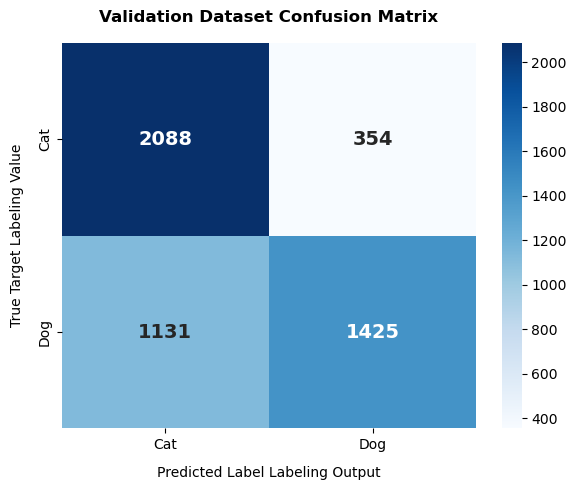

In [64]:
# Plot confusion matrix using Seaborn and Matplotlib [1]
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=class_names, 
    yticklabels=class_names,
    cbar=True,
    annot_kws={"size": 14, "weight": "bold"}
)
plt.title('Validation Dataset Confusion Matrix', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Predicted Label Labeling Output', fontsize=10, labelpad=10)
plt.ylabel('True Target Labeling Value', fontsize=10, labelpad=10)
plt.tight_layout()
plt.show()

In [65]:
# 10: Single Image Target Inference Testing with Confidence Parameters
def predict_external_image(target_file_path=r"D:\ml\image classification\test.jpg", min_confidence=0.75):
    try:
        if not os.path.exists(target_file_path):
            print(f"Error: The image file was not found at path: {target_file_path}")
            return
            
        img = keras.preprocessing.image.load_img(target_file_path, target_size=IMAGE_SIZE)
        img_array = keras.preprocessing.image.img_to_array(img)
        img_batch = np.expand_dims(img_array, axis=0)
        
        score_tensor = model.predict(img_batch, verbose=0)
        prediction_probability = float(score_tensor)       
        
        print("\n--- Single Image Inference Result Summary ---")
        
        dog_confidence = prediction_probability
        cat_confidence = 1.0 - prediction_probability
        
        if dog_confidence >= min_confidence:
            print(f"Classification Result: DOG ({dog_confidence * 100:.2f}% confidence)")
        elif cat_confidence >= min_confidence:
            print(f"Classification Result: CAT ({cat_confidence * 100:.2f}% confidence)")
        else:
            print(f"Classification Result: UNIDENTIFIED / UNKNOWN IMAGE")
            print(f"Reason: Model confidence falls below the {min_confidence * 100:.1f}% safety filter threshold.")
            print(f"Calculated Metrics -> Dog: {dog_confidence * 100:.2f}% | Cat: {cat_confidence * 100:.2f}%")
            
    except Exception as runtime_error:
        print(f"Inference process aborted for targeted file layout: {str(runtime_error)}")

# Call the prediction function to test your target file
predict_external_image()


--- Single Image Inference Result Summary ---
Classification Result: UNIDENTIFIED / UNKNOWN IMAGE
Reason: Model confidence falls below the 75.0% safety filter threshold.
Calculated Metrics -> Dog: 65.34% | Cat: 34.66%


C:\Users\dasde\AppData\Local\Temp\ipykernel_13988\1178019167.py:13: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  prediction_probability = float(score_tensor)


In [66]:
# 11: Single Image Target Inference Testing for either cat or dog classification
def predict_external_image(target_file_path="D:\ml\image classification\test1.jpg"):
    """
    Loads, processes dimensions, and evaluates an individual unseen image.
    """
    try:
        # 1. Verify if the file actually exists on the path provided
        if not os.path.exists(target_file_path):
            print(f"Error: The image file was not found at path: {target_file_path}")
            return
            
        # 2. Load and verify structural target image file matching model input dimensions
        img = keras.preprocessing.image.load_img(target_file_path, target_size=IMAGE_SIZE)
        img_array = keras.preprocessing.image.img_to_array(img)
        img_batch = np.expand_dims(img_array, axis=0) # Reshapes array layout to (1, 150, 150, 3)
        
        # 3. Calculate classification probability distribution signature
        score_tensor = model.predict(img_batch, verbose=0)
        
        # 4. Extract the exact float scalar value from the nested prediction array [[value]]
        prediction_probability = float(score_tensor[0][0])
        
        print("\n--- Inference Result Summary ---")
        # 5. Check standard binary classification threshold bounds (0: Cat, 1: Dog)
        if prediction_probability > 0.5:
            confidence = prediction_probability * 100
            print(f"Classification Result: DOG ({confidence:.2f}% confidence)")
        else:
            confidence = (1.0 - prediction_probability) * 100
            print(f"Classification Result: CAT ({confidence:.2f}% confidence)")
            
    except Exception as runtime_error:
        print(f"Inference process aborted for targeted file layout: {str(runtime_error)}")
# ==========================================
# ACTIVE INFERENCE EXECUTION BLOCK
# ==========================================
# Provide the full path to your local test image. 
# Make sure to keep the 'r' prefix before the path string to handle Windows backslashes correctly.
TEST_IMAGE_PATH = r"D:\ml\image classification\test1.jpg"

print(f"Running inference calculation on target file: {TEST_IMAGE_PATH}")
predict_external_image(TEST_IMAGE_PATH)


Running inference calculation on target file: D:\ml\image classification\test1.jpg

--- Inference Result Summary ---
Classification Result: CAT (76.38% confidence)
